# 🛫 Prévision des Retards Aériens — Notebook MLflow
**Projet PPML- FlyOnTime — 6 plus grands aéroports français**


### Configuration & Imports

In [1]:
import pandas as pd
import os
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from pandas.api.types import is_datetime64_any_dtype
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix
import mlflow

### Connexion MLflow

In [56]:
# --- 1. CONFIGURATION SERVEUR ---
MLFLOW_REMOTE_URI = "https://stoneray-ppml-mlflow.hf.space/"
mlflow.set_tracking_uri(MLFLOW_REMOTE_URI)

PRENOM = "Ludo"
TYPE_MODEL = "XGBoost" # Change ici : "XGBoost" ou "RandomForest"

EXPERIMENT_NAME = f"FlyOnTime_classif"
RUN_NAME        = f"{TYPE_MODEL}_classifier"
MODEL_NAME_TAG  = f"{TYPE_MODEL}_classifier_{PRENOM}"
REGISTERED_NAME = "FlyOnTime_classif"
ALIAS_NAME      = "challenger"

while mlflow.active_run():
    mlflow.end_run()
mlflow.set_experiment(EXPERIMENT_NAME)

print(f"✅ Connecté à : {MLFLOW_REMOTE_URI}")
print(f"🚀 Run : {RUN_NAME} | Tag : {MODEL_NAME_TAG}")

2026/04/17 23:52:35 INFO mlflow.tracking.fluent: Experiment with name 'FlyOnTime_classif' does not exist. Creating a new experiment.


✅ Connecté à : https://stoneray-ppml-mlflow.hf.space/
🚀 Run : XGBoost_classifier | Tag : XGBoost_classifier_Ludo


### Chargement des données

**Source :** AWS S3 (format Parquet)

**Datasets :**
- `df_train` → données historiques pour l'entraînement
- `df_predict` → données d'avril 2026 pour la prédiction finale

In [3]:
import boto3

# Fonction pour récupérer mes fichiers sur le bucket S3 de l'équipe
def charger_data_s3(chemin_fichier):
    # Setup de la session avec mes accès
    session = boto3.Session(
        aws_access_key_id=os.getenv("AWS_ACCESS_KEY_ID_EQUIPE"),
        aws_secret_access_key=os.getenv("AWS_SECRET_ACCESS_KEY_EQUIPE"),
        region_name="eu-north-1"
    )
    
    nom_bucket = os.getenv("BUCKET_EQUIPE")
    url_complete = f"s3://{nom_bucket}/{chemin_fichier}"
    
    print(f"Récupération du fichier : {chemin_fichier}...")
    
    
    if chemin_fichier.endswith('.csv'):
        return pd.read_csv(url_complete)
    else:
        return pd.read_parquet(url_complete)

# Chargement depuis S3
df_train = charger_data_s3("datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv")
df_predict = charger_data_s3("datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv")

# Je vérifie le format
print(f"Format Train   : {df_train.shape}")
print(f"Format Predict : {df_predict.shape}")

Récupération du fichier : datasets/SignofFlightsDataset_20260416_233018_CLEAN.csv...


C:\Users\surel\AppData\Local\Temp\ipykernel_21344\744087605.py:19: DtypeWarning: Columns (64,65,67,76,80,82,84,86) have mixed types. Specify dtype option on import or set low_memory=False.
  return pd.read_csv(url_complete)


Récupération du fichier : datasets/SignofFlightsDataset_future_20260416_233150_CLEAN.csv...
Format Train   : (94378, 96)
Format Predict : (4063, 96)


In [4]:
# Aperçu rapide des colonnes disponibles
print("Colonnes df_train :")
print(df_train.columns.tolist())
print("Colonnes df_predict :")
print(df_predict.columns.tolist())
print("---------------------------")
print("Aperçu df_train :")
df_train.head()


Colonnes df_train :
['flight_date', 'movement_date', 'flight_number', 'airline', 'airport_origin', 'airport_destination', 'terminal_departure', 'terminal_arrival', 'scheduled_departure', 'scheduled_arrival', 'estimated_departure', 'estimated_arrival', 'actual_departure', 'actual_arrival', 'actual_source_departure', 'actual_source_arrival', 'departure_delay_min', 'departure_advance_min', 'arrival_delay_min', 'arrival_advance_min', 'status', 'movement_type', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'cloud_base_dep', 'visibility_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunder

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


### On voit que la première ligne est inutile

In [5]:
print(df_train.iloc[0])
df = df_train.iloc[1:].reset_index(drop=True)
df_predict = df_predict.iloc[1:].reset_index(drop=True)


display(df_train.head())
print("-----------------------------------------------------------------------")
display(df_predict.head())

flight_date                             DATE_GENERATION
movement_date                       2026-04-17 03:31:48
flight_number                                       NaN
airline                                             NaN
airport_origin                                      NaN
                                           ...         
nombre_departs_destination                          NaN
nombre_arrivees_destination                         NaN
somme_depart_arrivee_destination                    NaN
congestion_destination                              NaN
retard arrivée                                      NaN
Name: 0, Length: 96, dtype: object


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-17 03:31:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-09-21,2025-09-21,AF 1249,Air France,MRS,CDG,NaN,2F,NaN,2025-09-21 23:10+02:00,...,NaN,137.0,131.0,268.0,1.0,680.0,654.0,1334.0,0.0,1.0
2,2025-09-21,2025-09-21,AF 6004,Air France,ORY,MRS,3,1,2025-09-21 09:15+02:00,2025-09-21 10:35+02:00,...,NaN,350.0,346.0,696.0,0.0,137.0,131.0,268.0,1.0,0.0
3,2025-09-21,2025-09-21,AF 6009,Air France,MRS,ORY,1,NaN,2025-09-21 16:20+02:00,NaN,...,NaN,137.0,131.0,268.0,1.0,350.0,346.0,696.0,0.0,1.0
4,2025-09-21,2025-09-21,AF 6104,Air France,ORY,TLS,3,NaN,2025-09-21 08:00+02:00,2025-09-21 09:15+02:00,...,NaN,350.0,346.0,696.0,0.0,79.0,82.0,161.0,0.0,0.0


-----------------------------------------------------------------------


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2026-04-17,2026-04-17,AF 6212,Air France,ORY,NCE,2,2,2026-04-17 12:35+02:00,2026-04-17 14:05+02:00,...,NaN,550.0,540.0,1090.0,1.0,179.0,177.0,356.0,0.0,0.0
1,2026-04-17,2026-04-17,AF 7300,Air France,CDG,NCE,2F,2,2026-04-17 06:45+02:00,2026-04-17 08:15+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
2,2026-04-17,2026-04-17,AF 7301,Air France,NCE,CDG,2,2F,2026-04-17 09:05+02:00,2026-04-17 10:40+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0
3,2026-04-17,2026-04-17,AF 7302,Air France,CDG,NCE,2F,2,2026-04-17 07:15+02:00,2026-04-17 08:50+02:00,...,NaN,NaN,NaN,NaN,0.0,179.0,177.0,356.0,0.0,0.0
4,2026-04-17,2026-04-17,AF 7303,Air France,NCE,CDG,2,2F,2026-04-17 09:45+02:00,2026-04-17 11:20+02:00,...,NaN,179.0,177.0,356.0,0.0,NaN,NaN,NaN,0.0,0.0


### --- Vérification des doublons ---
Normalement, un numéro de vol sur une même journée, c'est unique. 
Si j'en ai plusieurs, c'est qu'il y a un bug dans l'extraction.

In [6]:
# --- VÉRIFICATION DES DOUBLONS (Train & Predict) ---

# 1. Check sur les données d'entraînement
doublons_train = df_train[df_train.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"⚠️ Doublons dans le Train : {len(doublons_train)}")

# 2. Check sur les données futures (histoire d'être sûr)
doublons_predict = df_predict[df_predict.duplicated(subset=["flight_number", "flight_date"], keep=False)]
print(f"🔍 Doublons dans le Predict : {len(doublons_predict)}")

# Si j'ai un doute sur le futur, je regarde
if len(doublons_predict) > 0:
    print("Aperçu des doublons 'Futur' :")
    display(doublons_predict.sort_values(by=["flight_number", "flight_date"]).head(6))

⚠️ Doublons dans le Train : 1572
🔍 Doublons dans le Predict : 92
Aperçu des doublons 'Futur' :


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
162,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 12:35+02:00,2026-04-17 13:45+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
163,2026-04-17,2026-04-17,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-17 17:00+02:00,2026-04-17 18:10+02:00,...,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,0.0
1360,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 12:35+02:00,2026-04-19 13:45+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1361,2026-04-19,2026-04-19,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-19 16:40+02:00,2026-04-19 17:50+02:00,...,NaN,2245.0,2256.0,4501.0,0.0,239.0,243.0,482.0,1.0,0.0
1924,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 12:35+02:00,2026-04-20 13:45+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0
1925,2026-04-20,2026-04-20,AR 7826,Aerolineas Argentinas,CDG,LYS,2F,1,2026-04-20 17:00+02:00,2026-04-20 18:10+02:00,...,NaN,2241.0,2257.0,4498.0,0.0,246.0,253.0,499.0,1.0,0.0


Nous avons identifié que les doublons apparents ne correspondent pas à des escales, mais à deux lignes complémentaires décrivant un même vol : l’une pour le départ et l’autre pour l’arrivée. Il ne faut donc pas supprimer ces lignes ni les traiter séparément, car cela entraînerait une perte d’information et un biais dans le modèle. La bonne approche consiste à regrouper ces lignes pour reconstruire un vol complet en une seule observation, en combinant les informations de départ et d’arrivée (par exemple via un groupby et des agrégations adaptées).

In [7]:
# --- ANALYSE DES DOUBLONS (TRAIN & PREDICT) ---

# Définition des colonnes qui identifient un vol unique
cles_doublons = ["flight_number", "flight_date", "airport_origin", "airport_destination"]

# 1. Analyse pour le TRAIN
masque_train = df_train.duplicated(subset=cles_doublons, keep=False)
vols_doubles_train = df_train[masque_train]
vols_uniques_train = df_train[~masque_train]

# 2. Analyse pour le PREDICT
masque_predict = df_predict.duplicated(subset=cles_doublons, keep=False)
vols_doubles_predict = df_predict[masque_predict]
vols_uniques_predict = df_predict[~masque_predict]

# --- VÉRIFICATION DES THÉORIES ---
print(f"📊 TRAIN   : {len(vols_doubles_train)} lignes en doublons ({len(vols_doubles_train)//2} vols)")
print(vols_doubles_train["movement_type"].value_counts())

print(f"\n📊 PREDICT : {len(vols_doubles_predict)} lignes en doublons ({len(vols_doubles_predict)//2} vols)")
print(vols_doubles_predict["movement_type"].value_counts())

# Si les volumes Departure/Arrival sont quasi identiques, on confirme la structure "vols coupés en deux"

📊 TRAIN   : 1480 lignes en doublons (740 vols)
movement_type
departure    741
arrival      739
Name: count, dtype: int64

📊 PREDICT : 80 lignes en doublons (40 vols)
movement_type
departure    47
arrival      33
Name: count, dtype: int64


Il arrive que certain avions fassent plusieurs rotations par jour 
Quand on "recolle" le vol, on crée une seule ligne ultra-complète.
Avant (2 lignes) :
Ligne 1 : Vol AF1234 | Départ Paris | Vent 20km/h
Ligne 2 : Vol AF1234 | Arrivée Nice | Pluie | Retard 15min
Après (1 vol recollé) : Ligne Unique : Vol AF1234 | Départ Paris (Vent 20km/h) | Arrivée Nice (Pluie) | Retard 15min

In [8]:
# --- LA RÉPARATION (TRAIN & PREDICT) ---

def reparer_vols(df):
    # 1. Nettoyage de la ligne technique et conversion dates
    df = df.iloc[1:].reset_index(drop=True)
    dates_cols = ["flight_date", "scheduled_departure", "scheduled_arrival"]
    for c in dates_cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    masque = df.duplicated(subset=cles, keep=False)
    
    vols_solo = df[~masque].copy()
    vols_a_reparer = df[masque].copy()
    
    dep = vols_a_reparer[vols_a_reparer["movement_type"] == "departure"].sort_values("scheduled_departure")
    arr = vols_a_reparer[vols_a_reparer["movement_type"] == "arrival"].sort_values("scheduled_arrival")

    dep["n_vol"] = dep.groupby(cles).cumcount()
    arr["n_vol"] = arr.groupby(cles).cumcount()
    
    df_reconstruit = pd.merge(dep, arr, on=cles + ["n_vol"], suffixes=('_dep', '_arr'))
    
    return pd.concat([vols_solo, df_reconstruit], ignore_index=True)

df_train_final = reparer_vols(df_train)
df_predict_final = reparer_vols(df_predict)

# --- BILAN ---
print(f"✅ TRAIN   : {len(df_train_final)} vols prêts.")
print(f"✅ PREDICT : {len(df_predict_final)} vols prêts.")

C:\Users\surel\AppData\Local\Temp\ipykernel_21344\2513086950.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors="coerce")
C:\Users\surel\AppData\Local\Temp\ipykernel_21344\2513086950.py:9: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[c] = pd.to_datetime(df[c], errors="coerce")


✅ TRAIN   : 93584 vols prêts.
✅ PREDICT : 4014 vols prêts.


### --- BILAN DE SANTÉ FINAL ---
 Je rajoute l'heure de départ prévue ('scheduled_departure') dans le filtre pour prendre en compte l'heure de départ.

In [9]:
colonnes_cles = ['flight_number', 'flight_date', 'scheduled_departure']
 
nb_train = df_train_final.duplicated(subset=colonnes_cles).sum()
nb_predict = df_predict_final.duplicated(subset=colonnes_cles).sum()
print(f"Bilan de santé Train   : {nb_train} vrais doublons.")
print(f"Bilan de santé Predict : {nb_predict} vrais doublons.")
if nb_train + nb_predict == 0:
    print("\n✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.")
else:
    print("\n⚠️ Attention, il reste encore des rescapés à checker.")

Bilan de santé Train   : 0 vrais doublons.
Bilan de santé Predict : 0 vrais doublons.

✅ Nickel ! Tout est propre, chaque vol est désormais une ligne unique.


In [10]:
#%who DataFrame
#on travaille désormais sur df_train_final et df_predict_final, qui sont nos datasets réparés et prêts pour l'analyse et le modeling.

### On s'occupe des NaN 🫓

In [11]:
print(f"📏 Dimensions du TRAIN   : {df_train_final.shape} (Lignes, Colonnes)")
print(f"📏 Dimensions du PREDICT : {df_predict_final.shape} (Lignes, Colonnes)")

📏 Dimensions du TRAIN   : (93584, 281) (Lignes, Colonnes)
📏 Dimensions du PREDICT : (4014, 281) (Lignes, Colonnes)


In [12]:
def check_missing(df, name):
    print(f"\n🔍 ANALYSE : {name}")
    stats = (df.isna().mean() * 100).sort_values(ascending=False)
    stats_filtered = stats[stats > 0]
    if not stats_filtered.empty:
        print(stats_filtered.head(30))
    else:
        print("✅ Propre comme un sou neuf !")

check_missing(df_train_final, "TRAIN")
check_missing(df_predict_final, "PREDICT")


🔍 ANALYSE : TRAIN
Label Jour Ferié_arr      100.000000
cloud_base_arr_arr        100.000000
visibility_arr_arr        100.000000
visibility_dep_arr        100.000000
cloud_base_dep_arr        100.000000
visibility_arr_dep        100.000000
Label Jour Ferié_dep      100.000000
LABEL_TOULOUSE            100.000000
LABEL_TOULOUSE_arr        100.000000
cloud_base_dep_dep        100.000000
visibility_dep_dep        100.000000
cloud_base_arr            100.000000
LABEL_TOULOUSE_dep        100.000000
cloud_base_dep            100.000000
visibility_dep            100.000000
cloud_base_arr_dep        100.000000
visibility_arr            100.000000
LABEL_CDG_arr              99.998931
LABEL_CDG_dep              99.998931
LABEL_ORLY_arr             99.995726
LABEL_ORLY_dep             99.995726
LABEL_MARSEILLE_dep        99.976492
LABEL_MARSEILLE_arr        99.976492
LABEL_LYON_arr             99.973286
LABEL_LYON_dep             99.973286
LABEL_NICE_dep             99.961532
LABEL_NICE_arr     

In [13]:
def purger_et_voir(df, nom_dataset):
    print(f"\n--- 🗑️ NETTOYAGE : {nom_dataset} ---")
    colonnes_avant = set(df.columns)
    cles = ["flight_number", "flight_date", "airport_origin", "airport_destination"]
    # On protège tout ce qui contient "delay" ou "retard"
    mots_cles_proteges = ['delay', 'retard', 'target'] 
    
    cols_a_garder = [c for c in df.columns if 
                     c.endswith(('_dep', '_arr')) or 
                     c in cles or 
                     any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_filtre = df[cols_a_garder].copy()
    
    seuil = 0.6 
    taux_nan = df_filtre.isnull().mean()
    cols_trop_vides = [c for c in taux_nan[taux_nan > seuil].index 
                       if not any(mot in c.lower() for mot in mots_cles_proteges)]
    
    df_final = df_filtre.drop(columns=cols_trop_vides)
    
    fantômes = colonnes_avant - set(cols_a_garder)
    print(f"👻 {len(fantômes)} colonnes sans suffixe supprimées.")
    print(f"🏜️ {len(cols_trop_vides)} colonnes > {seuil*100}% vides supprimées.")
    print(f"🛡️ Colonnes de retard préservées : {[c for c in df_final.columns if any(mot in c.lower() for mot in mots_cles_proteges)]}")
    
    return df_final.ffill().bfill()

# On relance
df_train_final = purger_et_voir(df_train_final, "TRAIN")
df_predict_final = purger_et_voir(df_predict_final, "PREDICT")


--- 🗑️ NETTOYAGE : TRAIN ---
👻 48 colonnes sans suffixe supprimées.
🏜️ 182 colonnes > 60.0% vides supprimées.
🛡️ Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_delay_min_arr', 'retard arrivée_arr']

--- 🗑️ NETTOYAGE : PREDICT ---
👻 48 colonnes sans suffixe supprimées.
🏜️ 182 colonnes > 60.0% vides supprimées.
🛡️ Colonnes de retard préservées : ['departure_delay_min', 'arrival_delay_min', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_delay_min_arr', 'retard arrivée_arr']


In [14]:
def scan_total_vides(df, name):
    print(f"\n🕵️ SCAN COMPLET : {name}")
    nans = df.isna().sum().sum()
    
    vides = (df == "").sum().sum()
    placeholders = ["none", "null", "unknown", "missing", "nan", "undefined"]
    text_vides = df.apply(lambda x: x.astype(str).str.lower().isin(placeholders)).sum().sum()
    infinites = np.isinf(df.select_dtypes(include=np.number)).sum().sum()

    print(f"  - NaNs classiques      : {nans}")
    print(f"  - Textes vides ('' )   : {vides}")
    print(f"  - Mots-clés 'vides'    : {text_vides}")
    print(f"  - Valeurs infinies     : {infinites}")

scan_total_vides(df_train_final, "TRAIN")
scan_total_vides(df_predict_final, "PREDICT")


🕵️ SCAN COMPLET : TRAIN
  - NaNs classiques      : 0
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 0
  - Valeurs infinies     : 0

🕵️ SCAN COMPLET : PREDICT
  - NaNs classiques      : 24084
  - Textes vides ('' )   : 0
  - Mots-clés 'vides'    : 24084
  - Valeurs infinies     : 0


In [15]:
print("Columnes Train:", list(df_train_final.columns))
print("\nColumnes Predict:", list(df_predict_final.columns))
 
diff = set(df_train_final.columns) ^ set(df_predict_final.columns)
print(f"\n✅ Identiques : {not diff}" if not diff else f"⚠️ Différences : {diff}")

Columnes Train: ['flight_date', 'flight_number', 'airport_origin', 'airport_destination', 'departure_delay_min', 'arrival_delay_min', 'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep', 'temperature_2m_dep', 'cloud_cover_dep', 'time_arr', 'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr', 'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr', 'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr', 'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr', 'has_precipitation_arr', 'fog_arr', 'humidity_arr', 'temperature_2m_arr', 'cloud_cover_arr', 'retard arrivée', 'departure_delay_min_dep', 'arrival_delay_min_dep', 'retard arrivée_dep', 'departure_delay_min_arr', 'arrival_

### On définit la notion de retard

In [16]:
df_train_final["retard_arrivee"] = (df_train_final["arrival_delay_min_arr"] > 15).astype(int)
if "arrival_delay_min_arr" in df_predict_final.columns:
    df_predict_final["retard_arrivee"] = (df_predict_final["arrival_delay_min_arr"] > 15).astype(int)

print("✅ Colonne 'retard_arrivee' créée avec succès !")
print(f"Répartition dans le Train :\n{df_train_final['retard_arrivee'].value_counts()}")

✅ Colonne 'retard_arrivee' créée avec succès !
Répartition dans le Train :
retard_arrivee
1    93044
0      540
Name: count, dtype: int64


### MODELING

In [17]:
import mlflow
from dotenv import load_dotenv
import os

load_dotenv()

True

In [68]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
from xgboost import XGBClassifier
import mlflow.xgboost

PRENOM = "Ludo"
TYPE_MODEL = "XGBoost" 
EXPERIMENT_NAME = "FlyOnTime_classif"
RUN_NAME = f"{TYPE_MODEL}_classifier"
MODEL_NAME_TAG = f"{TYPE_MODEL}_classifier_{PRENOM}"
REGISTERED_NAME = "FlyOnTime_classif"
ALIAS_NAME = "challenger"

colonnes_dispo = df_train_final.columns.tolist()
nom_retard = next((c for c in colonnes_dispo if "arrival_delay_min" in c), None)

if nom_retard:
    df_train_final["target_retard"] = (df_train_final[nom_retard] > 15).astype(int)
    y = df_train_final["target_retard"]
else:
    raise ValueError("❌ Aucune colonne de retard trouvée pour créer la cible.")

#ANTI-LEAKAGE
cols_a_virer = [c for c in colonnes_dispo if any(x in c.lower() for x in ['delay', 'retard', 'target', 'time_dep', 'time_arr'])]
X = df_train_final.drop(columns=cols_a_virer)

datetime_cols = ["flight_date", "scheduled_departure_dep", "scheduled_arrival_arr"]
X_processed = X.copy()
for col in datetime_cols:
    if col in X_processed.columns:
        X_processed[col] = pd.to_datetime(X_processed[col], errors="coerce")
        X_processed[f"{col}_month"] = X_processed[col].dt.month
        X_processed[f"{col}_weekday"] = X_processed[col].dt.dayofweek
        X_processed[f"{col}_hour"] = X_processed[col].dt.hour
        X_processed = X_processed.drop(columns=[col])

#ENCODAGE DES CATÉGORIES (XGBoost)
cat_cols = X_processed.select_dtypes(include=["object", "category"]).columns.tolist()
encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_processed[cat_cols] = encoder.fit_transform(X_processed[cat_cols].astype(str))

# Séparation Train / Test
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)
mlflow.set_experiment(EXPERIMENT_NAME)

with mlflow.start_run(run_name=RUN_NAME+f"_{PRENOM}"):
    mlflow.xgboost.autolog()
    mlflow.set_tag("developer", PRENOM)
    mlflow.set_tag("model_full_name", MODEL_NAME_TAG)

    xgb_model = XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss'
    )

    print(f"🚀 Entraînement {TYPE_MODEL} en cours...")
    xgb_model.fit(X_train, y_train)

    # --- CALCUL DES MÉTRIQUES ---
    y_pred = xgb_model.predict(X_test)
    y_probs = xgb_model.predict_proba(X_test)[:, 1]

    metrics = {
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred),
        "test_recall": recall_score(y_test, y_pred),
        "test_f1": f1_score(y_test, y_pred),
        "test_auc": roc_auc_score(y_test, y_probs)
    }

    # Log de toutes les métriques dans MLflow
    mlflow.log_metrics(metrics)

    # --- MODEL REGISTRY ---
    model_info = mlflow.xgboost.log_model(
        xgb_model, 
        artifact_path="model", 
        registered_model_name=REGISTERED_NAME
    )
    
    client = mlflow.tracking.MlflowClient()
    client.set_registered_model_alias(REGISTERED_NAME, ALIAS_NAME, str(model_info.registered_model_version))

    # --- AFFICHAGE FINAL ---
    print(f"\n📊 RÉSULTATS DU MODÈLE :")
    for name, value in metrics.items():
        print(f"🔹 {name.replace('test_', '').capitalize()}: {value:.4f}")
    
    print(f"\n✅ Modèle enregistré : {REGISTERED_NAME} @{ALIAS_NAME}")

🚀 Entraînement XGBoost en cours...


2026/04/18 00:16:00 WARNING mlflow.utils.autologging_utils: MLflow autologging encountered a warning: "c:\Users\surel\anaconda3\envs\ds_classic\Lib\site-packages\mlflow\types\utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details."
2026/04/18 00:16:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/18 00:16:16 WARNING mlflow.


📊 RÉSULTATS DU MODÈLE :
🔹 Accuracy: 0.8511
🔹 Precision: 0.8346
🔹 Recall: 0.6582
🔹 F1: 0.7360
🔹 Auc: 0.9131

✅ Modèle enregistré : FlyOnTime_classif @challenger
🏃 View run XGBoost_classifier_Ludo at: https://stoneray-ppml-mlflow.hf.space/#/experiments/12/runs/0d6e07c4634843978cbdd4f496d03090
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/12


C:\Users\surel\AppData\Local\Temp\ipykernel_21344\1041221212.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')
c:\Users\surel\anaconda3\envs\ds_classic\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128640 (\N{ROCKET}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


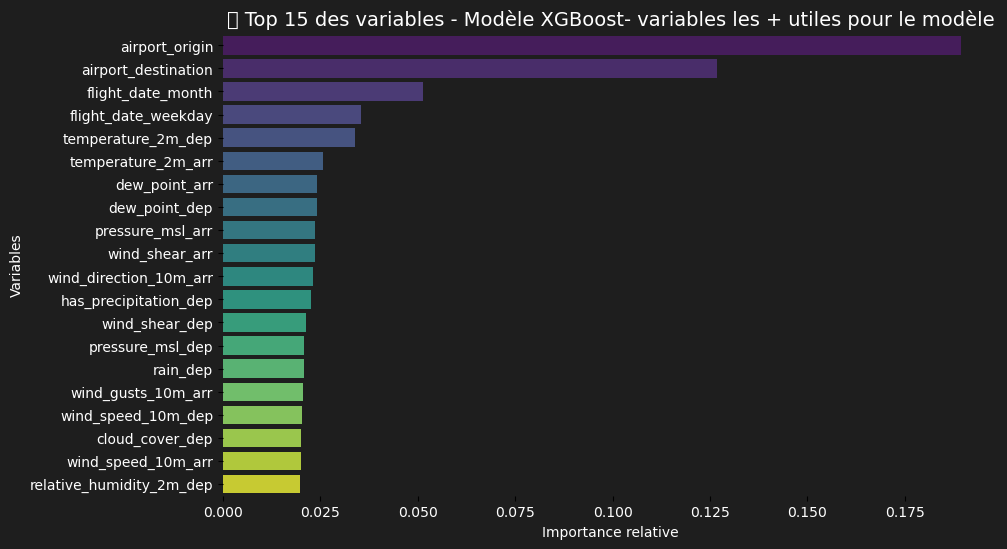

In [70]:
# 1. On récupère les importances
importances = xgb_model.feature_importances_

#  récupère les noms des colonnes directement utilisés par le modèle
labels = xgb_model.get_booster().feature_names
# Si jamais le modèle n'a pas enregistré les noms, on utilise X_train
if labels is None:
    labels = X_train.columns 
if len(labels) != len(importances):
    print(f"⚠️ Erreur de taille : Labels ({len(labels)}) vs Importances ({len(importances)})")
    min_len = min(len(labels), len(importances))
    feature_df = pd.DataFrame({'Feature': labels[:min_len], 'Importance': importances[:min_len]})
else:
    feature_df = pd.DataFrame({'Feature': labels, 'Importance': importances})

feature_df = feature_df.sort_values(by='Importance', ascending=False).head(20)

plt.figure(figsize=(10, 6), facecolor='#1E1E1E')
ax = sns.barplot(x='Importance', y='Feature', data=feature_df, palette='viridis')

ax.set_facecolor('#1E1E1E')
ax.set_title(f'🚀 Top 15 des variables - Modèle {TYPE_MODEL}- variables les + utiles pour le modèle', color='white', fontsize=14)
ax.set_xlabel('Importance relative', color='white')
ax.set_ylabel('Variables', color='white')
plt.xticks(color='white')
plt.yticks(color='white')
sns.despine(left=True, bottom=True)

plt.show()

# Prédire le futur

In [71]:
# 1. Préparation des données de prédiction
X_predict = df_predict_final.drop(columns=[c for c in colonnes_a_virer if c in df_predict_final.columns])
X_predict_processed = extract_date_features(X_predict, datetime_cols)

# 2. Prédictions
predictions = model.predict(X_predict_processed)
probabilities = model.predict_proba(X_predict_processed)[:, 1]

# 3. Création de df_resultats
df_resultats = df_predict_final.copy()
df_resultats["prediction_retard"] = predictions
df_resultats["Confiance"] = (probabilities * 100).round(1)
df_resultats["Prédiction"] = np.where(predictions == 1, "⚠️ RETARD", "✅ À L'HEURE")

print("✅ Variable 'df_resultats' recréée avec succès.")

✅ Variable 'df_resultats' recréée avec succès.


In [42]:
df_resultats.head()

,flight_date,flight_number,airport_origin,airport_destination,departure_delay_min,arrival_delay_min,time_dep,relative_humidity_2m_dep,dew_point_dep,icing_conditions_dep,...,departure_delay_min_dep,arrival_delay_min_dep,retard arrivée_dep,departure_delay_min_arr,arrival_delay_min_arr,retard arrivée_arr,retard_arrivee,prediction_retard,Confiance,Prédiction
0,2026-04-17,AF 7300,CDG,NCE,NaN,NaN,2026-04-17 04:00:00+00:00,83.0,6.1,Non,...,NaN,NaN,0.0,NaN,NaN,0.0,0,1,58.2,⚠️ RETARD
1,2026-04-17,AF 7301,NCE,CDG,NaN,NaN,2026-04-17 07:00:00+00:00,76.0,13.5,Non,...,NaN,NaN,0.0,NaN,NaN,0.0,0,0,33.3,✅ À L'HEURE
2,2026-04-17,AF 7302,CDG,NCE,NaN,NaN,2026-04-17 05:00:00+00:00,83.0,5.9,Non,...,NaN,NaN,0.0,NaN,NaN,0.0,0,1,57.8,⚠️ RETARD
3,2026-04-17,AF 7303,NCE,CDG,NaN,NaN,2026-04-17 07:00:00+00:00,76.0,13.5,Non,...,NaN,NaN,0.0,NaN,NaN,0.0,0,0,29.5,✅ À L'HEURE
4,2026-04-17,AF 7304,CDG,NCE,NaN,NaN,2026-04-17 06:00:00+00:00,82.0,6.0,Non,...,NaN,NaN,0.0,NaN,NaN,0.0,0,1,56.4,⚠️ RETARD


### Petit visuel sympa 

In [ ]:
from ipywidgets import interact

c_orig = next(c for c in ["airport_origin", "airport_origin_dep"] if c in df_resultats)
c_dest = next(c for c in ["airport_destination", "airport_destination_arr"] if c in df_resultats)
cols = [c for c in ["flight_number", "time_dep", c_orig, c_dest, "Prédiction", "Confiance"] if c in df_resultats]
dates = sorted(df_resultats["flight_date"].astype(str).unique())
villes = sorted(df_resultats[c_orig].unique())
@interact(Aeroport=villes, Date=dates)
def show_dash(Aeroport, Date):
    df = df_resultats[(df_resultats[c_orig] == Aeroport) & (df_resultats["flight_date"].astype(str) == Date)]
    if df.empty: return print("📭 Aucun vol trouvé.")
    print(f"✈️ {Aeroport} | {Date} ({len(df)} vols)")
    display(df[cols].style
        .set_properties(**{'background-color': '#1E1E1E', 'color': 'white', 'border': '1px solid #444'})
        .applymap(color_retard_dark, subset=['Prédiction'])
        .background_gradient(cmap='RdYlGn_r', subset=['Confiance'], vmin=0, vmax=100)
        .format({"Confiance": "{:.1f}%"}))

interactive(children=(Dropdown(description='Aeroport', options=('CDG', 'LYS', 'MRS', 'NCE', 'ORY', 'TLS'), val…